# Wikipedia Usage – Business Analytics EDA
**Project:** Analyzing Wikipedia's user engagement, platform health, and competitive position against AI tools  
**Dataset:** Primary survey data (1134 respondents)  
**Goal:** Derive actionable business insights from user behavior trends, trust metrics, and feature demand

## 1. Setup & Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Plot aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
COLORS = sns.color_palette('Set2')
print('Libraries loaded ✅')

Libraries loaded ✅


## 2. Load & Clean Data

In [4]:
df = pd.read_csv('BA_wikipedia.txt')  # adjust path if needed

# Rename columns for convenience
df.columns = [
    'id','start_time','completion_time','email','name_blank','name',
    'age','gender','education','field',
    'wiki_freq','chatgpt_freq','first_open',
    'wiki_usage_change','why_wiki','why_chatgpt',
    'trust_more','wiki_feels','ai_feels',
    'choose_ai_over_wiki','frustration_wiki',
    'ai_summary_interest','prefer_format',
    'would_use_if','future_likelihood','feature_to_return'
]

# Parse timestamps
df['start_time'] = pd.to_datetime(df['start_time'], dayfirst=False, errors='coerce')
df['completion_time'] = pd.to_datetime(df['completion_time'], dayfirst=False, errors='coerce')
df['response_time_min'] = (df['completion_time'] - df['start_time']).dt.total_seconds() / 60
df['survey_date'] = df['start_time'].dt.date

# Clean age & likelihood
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['future_likelihood'] = pd.to_numeric(df['future_likelihood'], errors='coerce')

# Drop rows with critical nulls
df.dropna(subset=['age','gender','wiki_freq'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Shape: {df.shape}')
df.head(3)

Shape: (1134, 28)


,id,start_time,completion_time,email,name_blank,name,age,gender,education,field,...,ai_feels,choose_ai_over_wiki,frustration_wiki,ai_summary_interest,prefer_format,would_use_if,future_likelihood,feature_to_return,response_time_min,survey_date
0,1,2026-02-23 08:08:00,2026-02-23 08:10:00,anonymous,NaN,Anuja,18,Female,High school,Engineering,...,Risk of incorrect answers,No need to read long pages,Too much reading,Yes,AI summary + Original Wikipedia article,Personalized recommendations,7.0,Faster access,2.0,2026-02-23
1,2,2026-02-23 08:08:00,2026-02-23 08:11:00,anonymous,NaN,Srujana,19,Female,High school,Engineering,...,More personalized,Personalized explanation,Not beginner friendly,No,AI summary + Original Wikipedia article,Simplified student mode,6.0,Authenticity with personalised responses,3.0,2026-02-23
2,3,2026-02-23 08:12:00,2026-02-23 08:15:00,anonymous,NaN,Kavinayaa,17,Female,Bachelor's degree,Engineering,...,More personalized,Personalized explanation,No interaction,Maybe,AI summary + Original Wikipedia article,Personalized recommendations,5.0,I'm not sure,3.0,2026-02-23


In [5]:
# Missing value summary
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

name_blank           1134
feature_to_return       2
dtype: int64

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,1134.0,NaN,NaN,NaN,567.5,1.0,284.25,567.5,850.75,1134.0,327.501908
start_time,1134,NaN,NaN,NaN,2026-03-09 04:33:15.767195,2026-02-23 08:08:00,2026-02-28 20:52:00,2026-03-09 09:51:00,2026-03-17 04:53:00,2026-03-25 07:33:00,NaN
completion_time,1134,NaN,NaN,NaN,2026-03-09 04:41:24.232804,2026-02-23 08:10:00,2026-02-28 20:58:30,2026-03-09 09:57:30,2026-03-17 05:06:00,2026-03-25 07:43:00,NaN
email,1134,1,anonymous,1134,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name_blank,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,1134,1104,Padma Achuthan,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1134.0,NaN,NaN,NaN,20.609347,17.0,19.0,21.0,22.0,67.0,2.795145
gender,1134,2,Female,685,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,1134,12,Bachelor's degree,192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
field,1134,42,Engineering,79,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Respondent Demographics

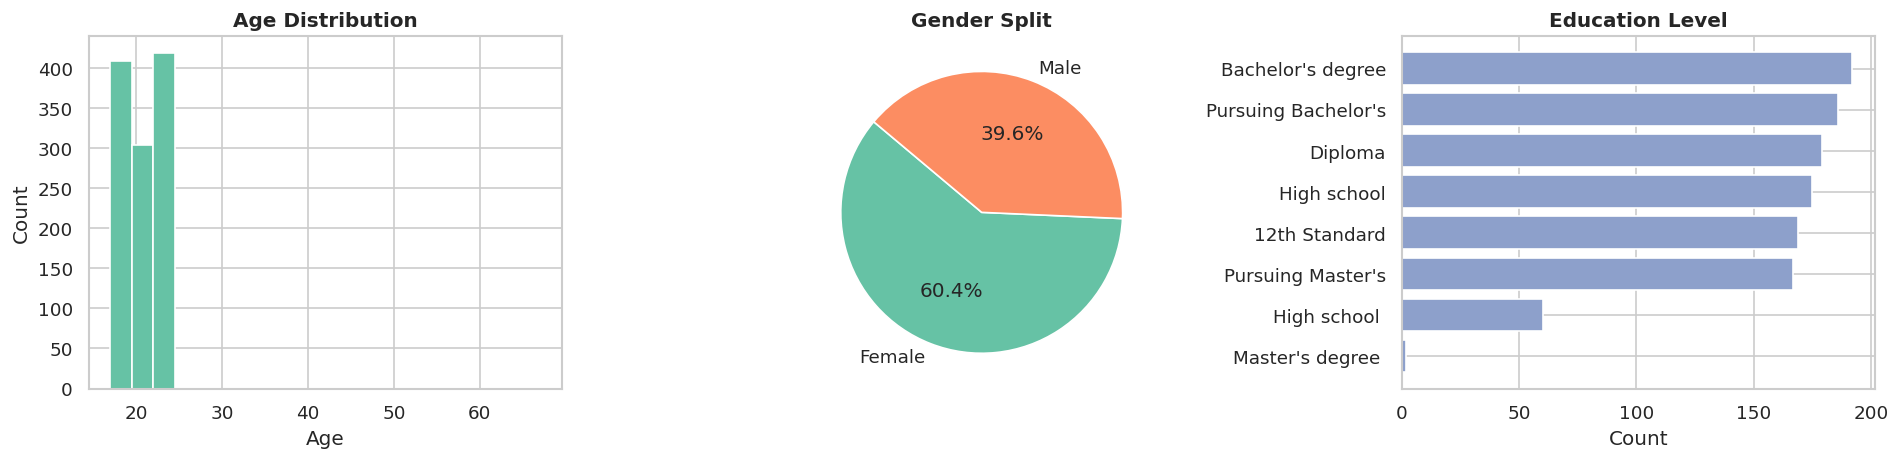

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Age distribution
axes[0].hist(df['age'].dropna(), bins=20, color=COLORS[0], edgecolor='white')
axes[0].set_title('Age Distribution', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Gender
gc = df['gender'].value_counts()
axes[1].pie(gc, labels=gc.index, autopct='%1.1f%%', colors=COLORS, startangle=140)
axes[1].set_title('Gender Split', fontweight='bold')

# Education
ec = df['education'].value_counts().head(8)
axes[2].barh(ec.index[::-1], ec.values[::-1], color=COLORS[2])
axes[2].set_title('Education Level', fontweight='bold')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('demographics.png', bbox_inches='tight')
plt.show()

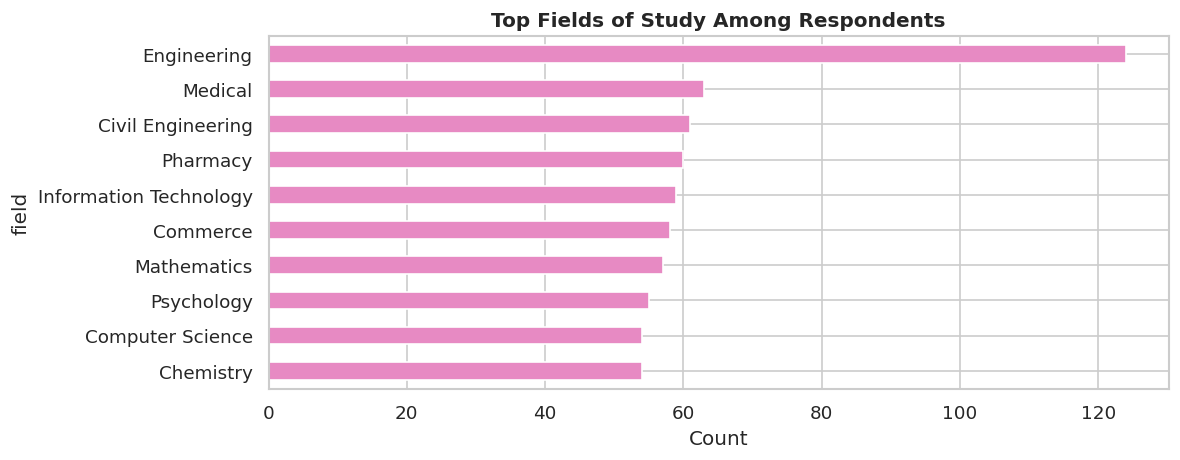

field
Engineering               124
Medical                    63
Civil Engineering          61
Pharmacy                   60
Information Technology     59
Commerce                   58
Mathematics                57
Psychology                 55
Computer Science           54
Chemistry                  54
Name: count, dtype: int64


In [8]:
# Top fields of study
field_counts = df['field'].str.strip().value_counts().head(10)
plt.figure(figsize=(10, 4))
field_counts[::-1].plot(kind='barh', color=COLORS[3])
plt.title('Top Fields of Study Among Respondents', fontweight='bold')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('fields.png', bbox_inches='tight')
plt.show()
print(field_counts)

## 4. Platform Usage Frequency

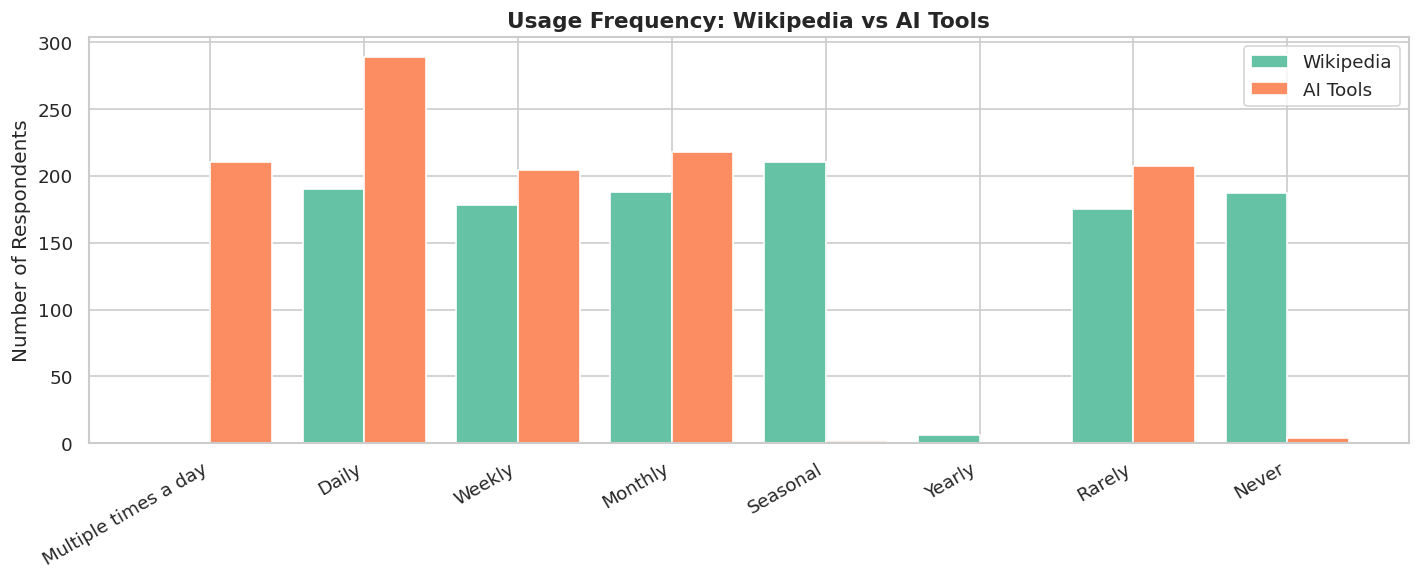

Daily+ Wikipedia users : 16.8%
Daily+ AI Tools users  : 44.0%


In [9]:
# Order categories
freq_order = ['Multiple times a day','Daily','Weekly','Monthly','Seasonal','Yearly','Rarely','Never']

wiki_freq = df['wiki_freq'].value_counts().reindex(freq_order, fill_value=0)
ai_freq   = df['chatgpt_freq'].value_counts().reindex(freq_order, fill_value=0)

x = np.arange(len(freq_order))
width = 0.4
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, wiki_freq.values, width, label='Wikipedia', color=COLORS[0])
ax.bar(x + width/2, ai_freq.values,   width, label='AI Tools',  color=COLORS[1])
ax.set_xticks(x)
ax.set_xticklabels(freq_order, rotation=30, ha='right')
ax.set_title('Usage Frequency: Wikipedia vs AI Tools', fontweight='bold', fontsize=13)
ax.set_ylabel('Number of Respondents')
ax.legend()
plt.tight_layout()
plt.savefig('usage_freq.png', bbox_inches='tight')
plt.show()

# Insight summary
wiki_daily_pct = (wiki_freq[['Multiple times a day','Daily']].sum() / len(df) * 100).round(1)
ai_daily_pct   = (ai_freq[['Multiple times a day','Daily']].sum() / len(df) * 100).round(1)
print(f'Daily+ Wikipedia users : {wiki_daily_pct}%')
print(f'Daily+ AI Tools users  : {ai_daily_pct}%')

## 5. Wikipedia Usage Trend (Has it Grown or Declined?)

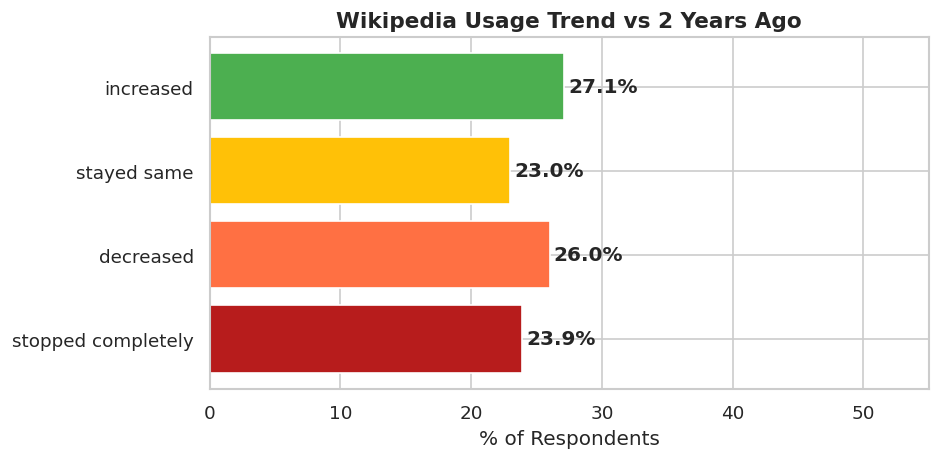

wiki_usage_change_clean
increased             27.1
stayed same           23.0
decreased             26.0
stopped completely    23.9
Name: count, dtype: float64


In [10]:
# Normalize varied spellings
df['wiki_usage_change_clean'] = df['wiki_usage_change'].str.strip().str.lower()
df['wiki_usage_change_clean'] = df['wiki_usage_change_clean'].replace({
    'stayed the same': 'stayed same',
    'stayed same': 'stayed same'
})

change_order = ['increased','stayed same','decreased','stopped completely']
change_counts = df['wiki_usage_change_clean'].value_counts().reindex(change_order, fill_value=0)
change_pct    = (change_counts / len(df) * 100).round(1)

colors_map = ['#4CAF50','#FFC107','#FF7043','#B71C1C']
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(change_order[::-1], change_pct.values[::-1], color=colors_map[::-1])
for bar, val in zip(bars, change_pct.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontweight='bold')
ax.set_xlabel('% of Respondents')
ax.set_title('Wikipedia Usage Trend vs 2 Years Ago', fontweight='bold', fontsize=13)
ax.set_xlim(0, 55)
plt.tight_layout()
plt.savefig('usage_trend.png', bbox_inches='tight')
plt.show()
print(change_pct)

## 6. First-Stop Information Source

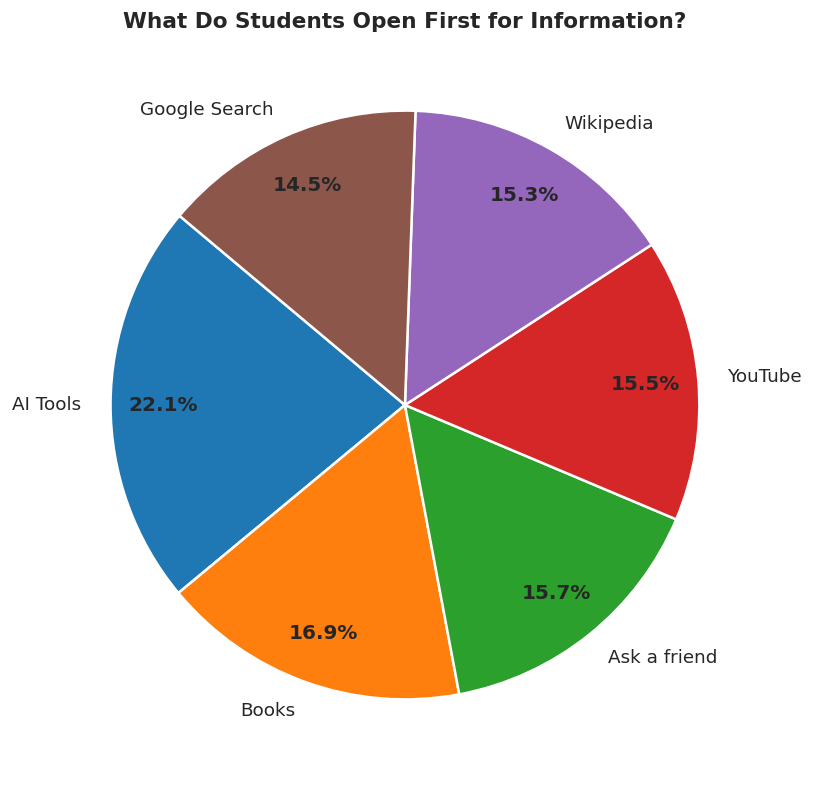

first_open
AI Tools         251
Books            192
Ask a friend     178
YouTube          176
Wikipedia        173
Google Search    164
Name: count, dtype: int64


In [11]:
fo = df['first_open'].str.strip().value_counts()
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    fo.values, labels=fo.index, autopct='%1.1f%%',
    colors=sns.color_palette('tab10', len(fo)), startangle=140,
    pctdistance=0.82, wedgeprops=dict(linewidth=1.5, edgecolor='white')
)
for t in autotexts:
    t.set_fontweight('bold')
ax.set_title('What Do Students Open First for Information?', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('first_open.png', bbox_inches='tight')
plt.show()
print(fo)

## 7. Trust Analysis: Wikipedia vs AI Tools

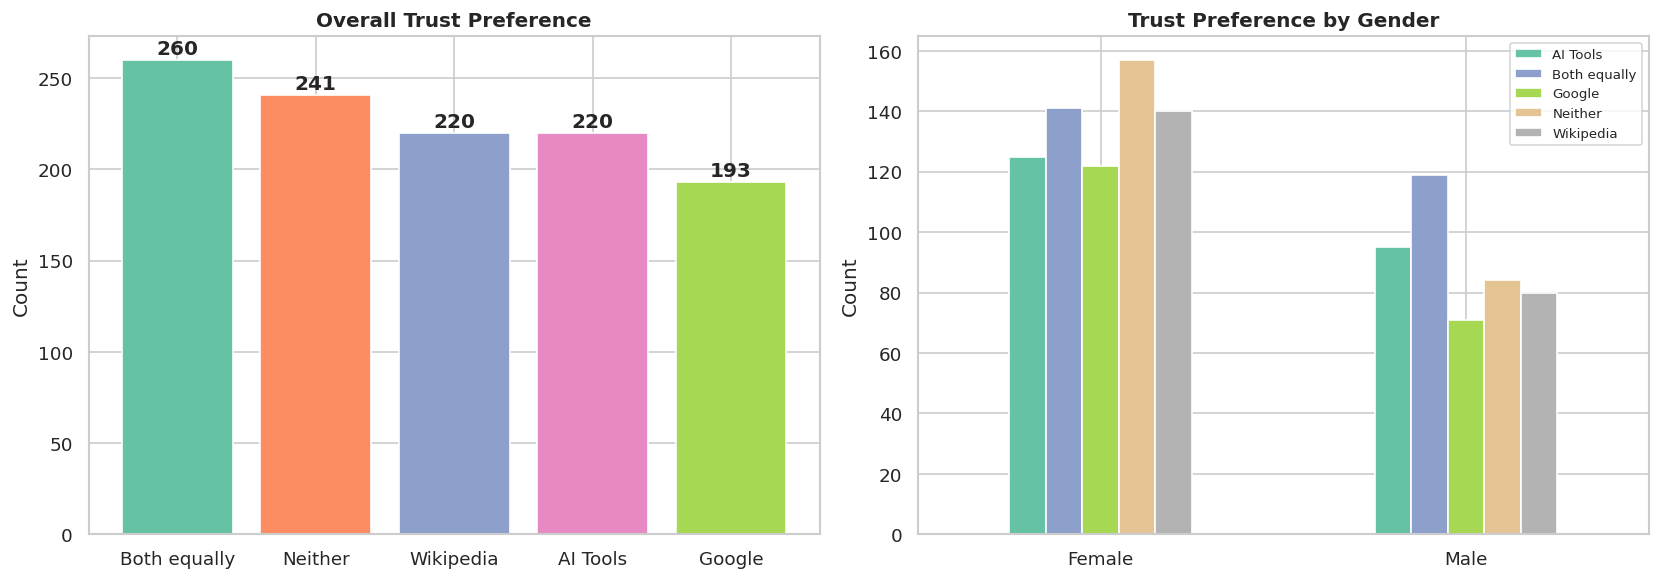

trust_more
Both equally    22.9
Neither         21.3
Wikipedia       19.4
AI Tools        19.4
Google          17.0
Name: count, dtype: float64


In [12]:
trust = df['trust_more'].str.strip().value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall trust
axes[0].bar(trust.index, trust.values, color=COLORS)
axes[0].set_title('Overall Trust Preference', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(trust.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Trust by gender
trust_gender = df.groupby(['gender','trust_more']).size().unstack(fill_value=0)
trust_gender.plot(kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('Trust Preference by Gender', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('trust.png', bbox_inches='tight')
plt.show()
print((trust / len(df) * 100).round(1))

## 8. Why Users Choose Each Platform (Multi-select Analysis)

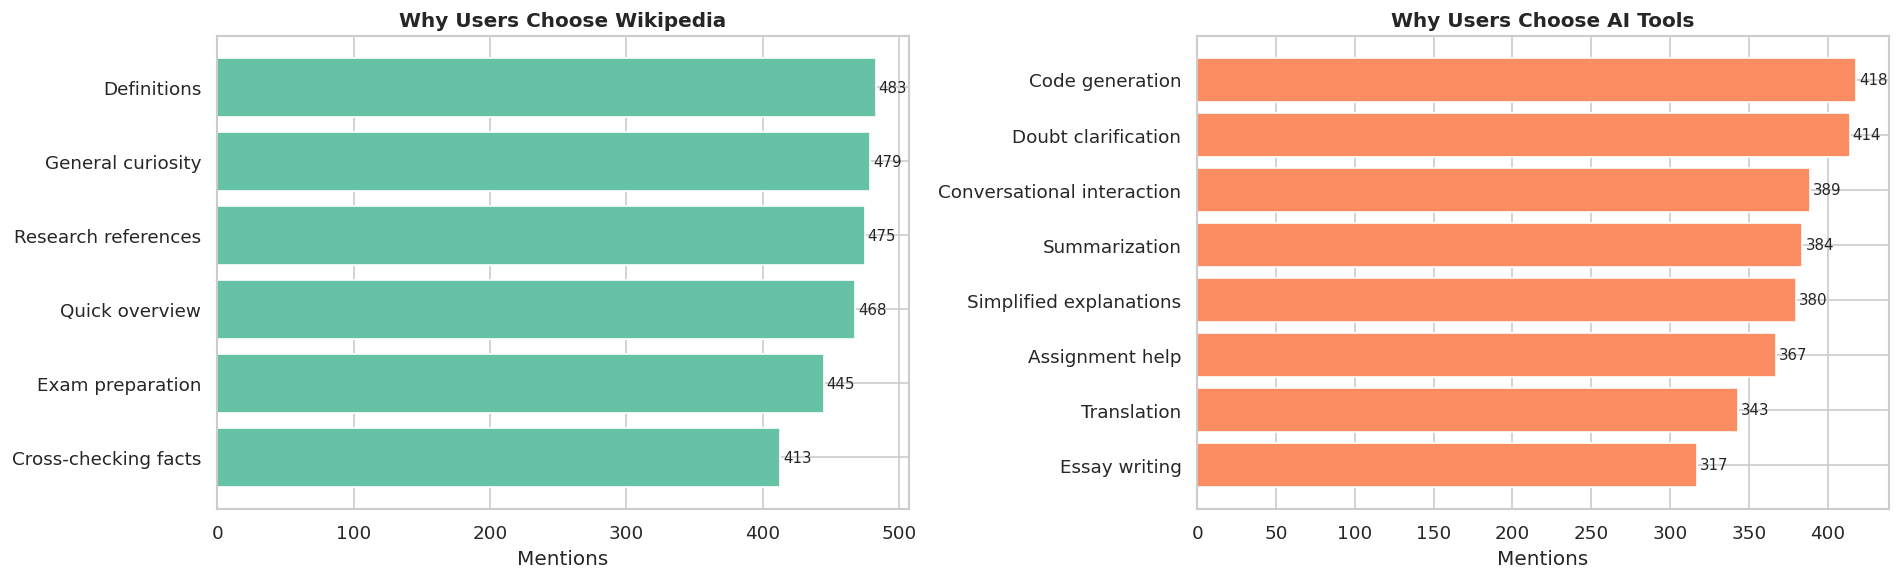

In [13]:
def explode_multi(series, sep=';'):
    """Flatten multi-select column into a Counter."""
    all_items = []
    for row in series.dropna():
        items = [x.strip() for x in str(row).split(sep) if x.strip()]
        all_items.extend(items)
    return Counter(all_items)

wiki_reasons = explode_multi(df['why_wiki'])
ai_reasons   = explode_multi(df['why_chatgpt'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, counter, title, color in [
    (axes[0], wiki_reasons, 'Why Users Choose Wikipedia', COLORS[0]),
    (axes[1], ai_reasons,   'Why Users Choose AI Tools',  COLORS[1])
]:
    labels, vals = zip(*counter.most_common(10))
    ax.barh(labels[::-1], vals[::-1], color=color)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Mentions')
    for i, v in enumerate(vals[::-1]):
        ax.text(v + 2, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('why_platform.png', bbox_inches='tight')
plt.show()

## 9. Platform Perception: How Users Feel

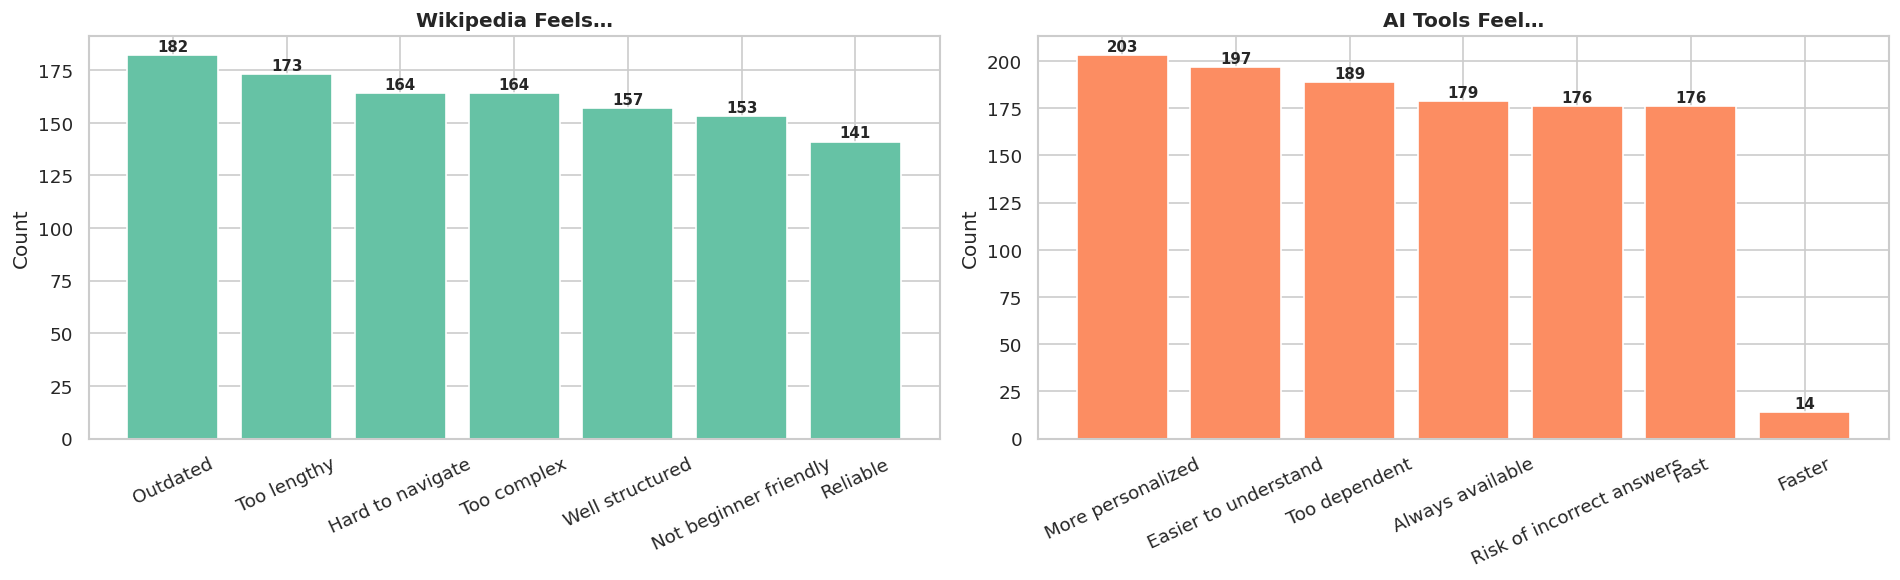

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, title, color in [
    (axes[0], 'wiki_feels',   'Wikipedia Feels…',  COLORS[0]),
    (axes[1], 'ai_feels',     'AI Tools Feel…',    COLORS[1])
]:
    counts = df[col].str.strip().value_counts()
    ax.bar(counts.index, counts.values, color=color)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=25)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 2, str(v), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('perception.png', bbox_inches='tight')
plt.show()

## 10. Pain Points: What Frustrates Users About Wikipedia

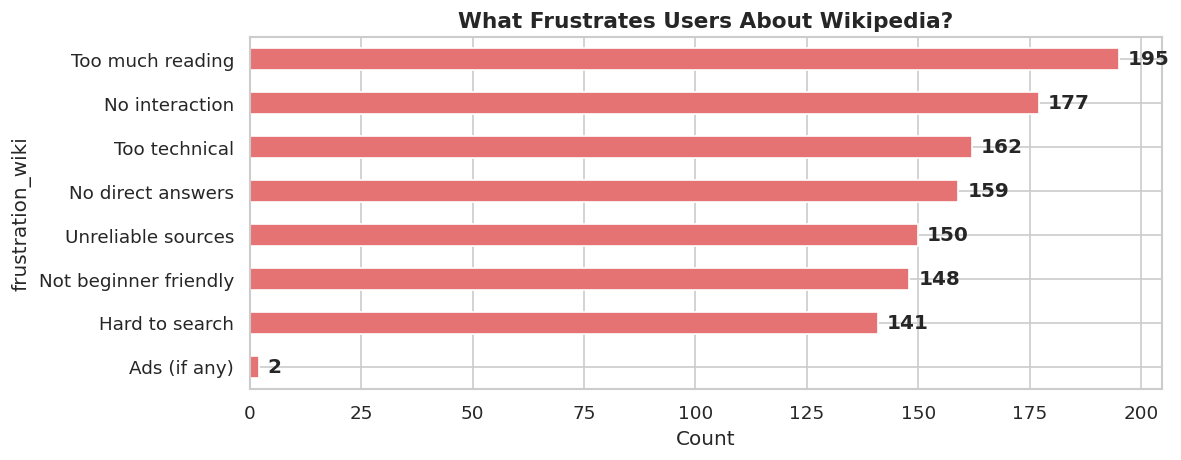

frustration_wiki
Too much reading         17.2
No interaction           15.6
Too technical            14.3
No direct answers        14.0
Unreliable sources       13.2
Not beginner friendly    13.1
Hard to search           12.4
Ads (if any)              0.2
Name: count, dtype: float64


In [15]:
frustrations = df['frustration_wiki'].str.strip().value_counts()
plt.figure(figsize=(10, 4))
frustrations[::-1].plot(kind='barh', color='#E57373')
plt.title('What Frustrates Users About Wikipedia?', fontweight='bold', fontsize=13)
plt.xlabel('Count')
for i, v in enumerate(frustrations.values[::-1]):
    plt.text(v + 2, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('frustrations.png', bbox_inches='tight')
plt.show()
print((frustrations / len(df) * 100).round(1))

## 11. Reasons Users Choose AI Over Wikipedia

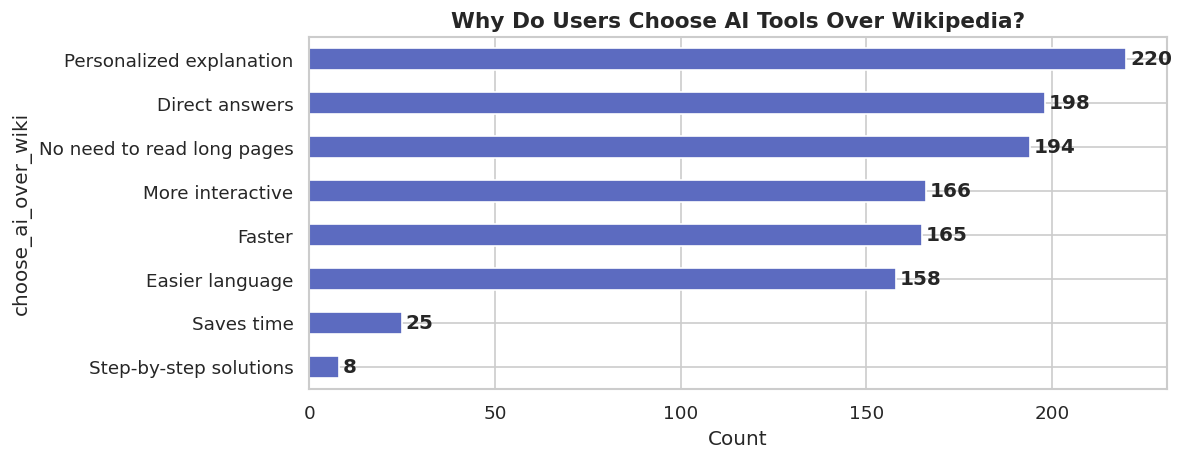

choose_ai_over_wiki
Personalized explanation      19.4
Direct answers                17.5
No need to read long pages    17.1
More interactive              14.6
Faster                        14.6
Easier language               13.9
Saves time                     2.2
Step-by-step solutions         0.7
Name: count, dtype: float64


In [16]:
ai_over = df['choose_ai_over_wiki'].str.strip().value_counts()
plt.figure(figsize=(10, 4))
ai_over[::-1].plot(kind='barh', color='#5C6BC0')
plt.title('Why Do Users Choose AI Tools Over Wikipedia?', fontweight='bold', fontsize=13)
plt.xlabel('Count')
for i, v in enumerate(ai_over.values[::-1]):
    plt.text(v + 1, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('ai_over_wiki.png', bbox_inches='tight')
plt.show()
print((ai_over / len(df) * 100).round(1))

## 12. AI Summary Feature Demand

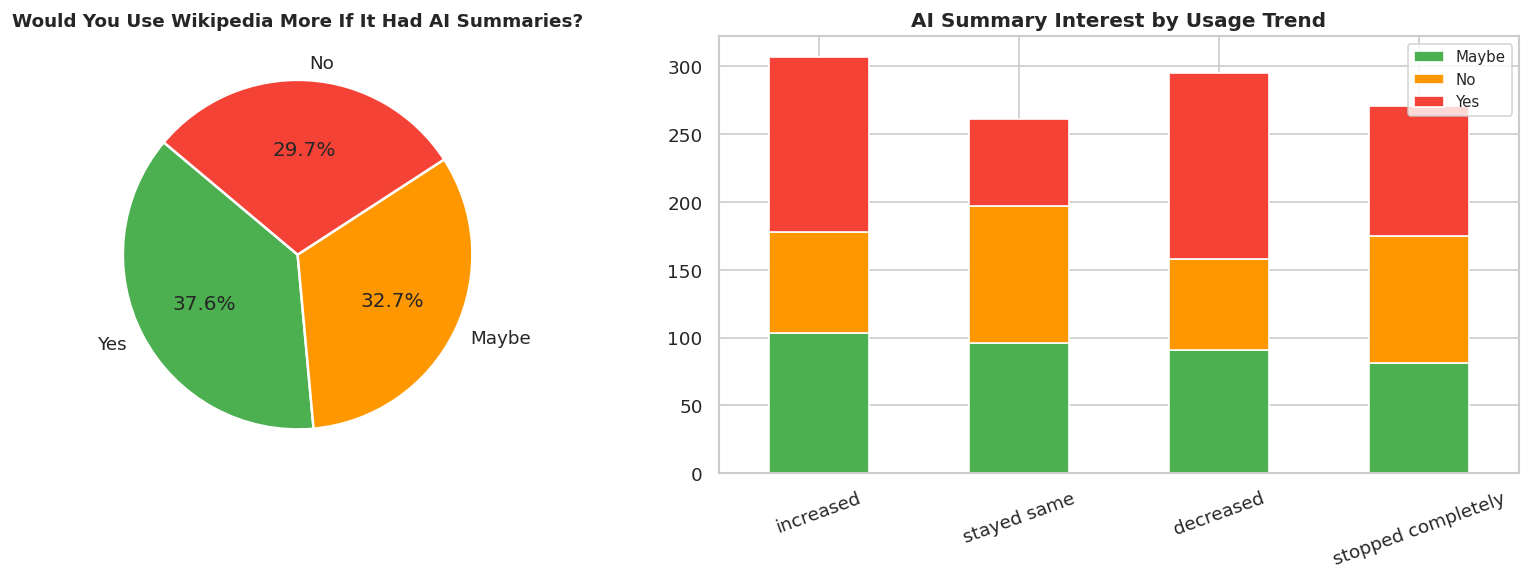

ai_summary_interest
Yes      426
Maybe    371
No       337
Name: count, dtype: int64


In [17]:
ai_sum = df['ai_summary_interest'].str.strip().value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall
axes[0].pie(ai_sum.values, labels=ai_sum.index,
            autopct='%1.1f%%', colors=['#4CAF50','#FF9800','#F44336'],
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title('Would You Use Wikipedia More If It Had AI Summaries?',
                  fontweight='bold', fontsize=11)

# By usage change
cross = pd.crosstab(df['wiki_usage_change_clean'], df['ai_summary_interest'].str.strip())
cross = cross.reindex(change_order, fill_value=0)
cross.plot(kind='bar', ax=axes[1], stacked=True,
           color=['#4CAF50','#FF9800','#F44336'], edgecolor='white')
axes[1].set_title('AI Summary Interest by Usage Trend', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('ai_summary.png', bbox_inches='tight')
plt.show()
print(ai_sum)

## 13. Preferred Format & Feature Wishlist

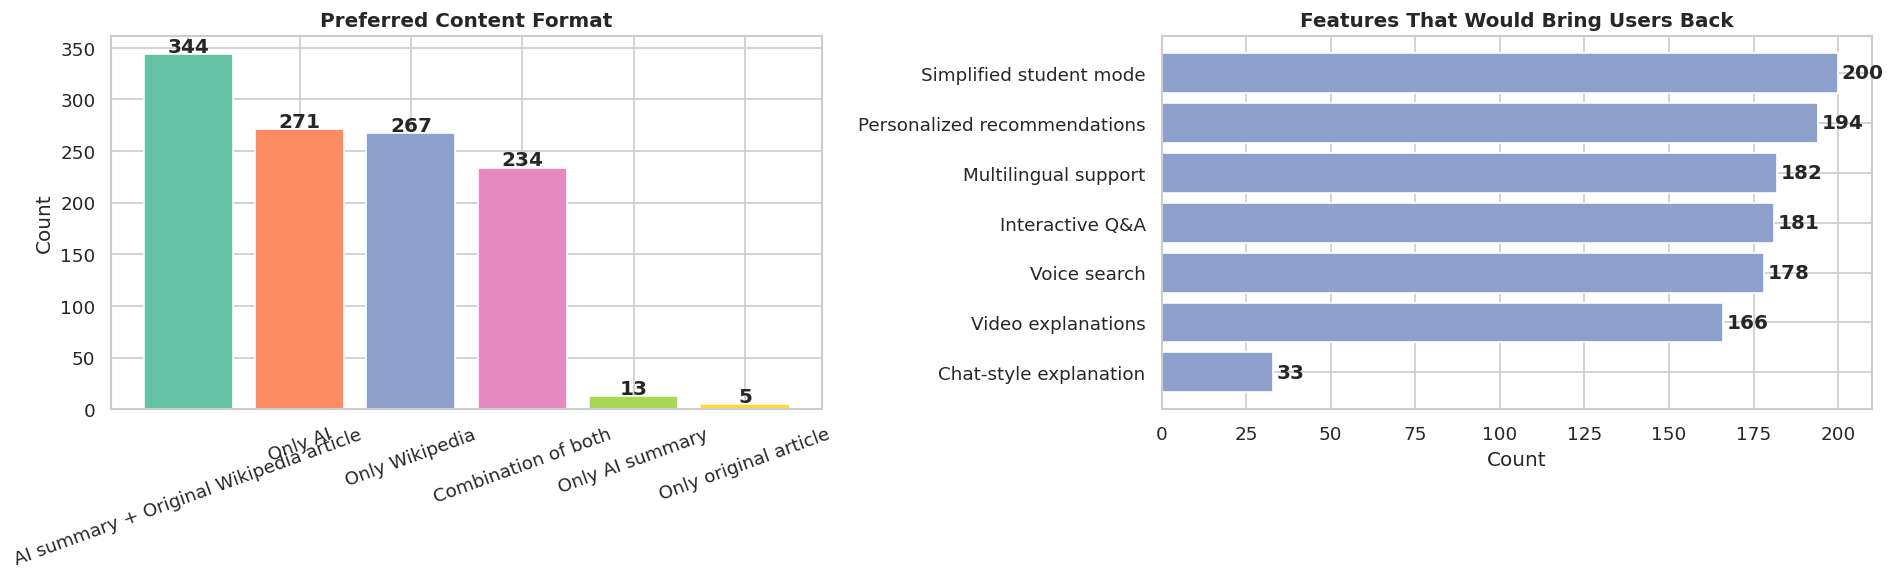

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Preferred format
pf = df['prefer_format'].str.strip().value_counts()
axes[0].bar(pf.index, pf.values, color=COLORS)
axes[0].set_title('Preferred Content Format', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(pf.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Feature wishlist
feat = df['would_use_if'].str.strip().value_counts()
axes[1].barh(feat.index[::-1], feat.values[::-1], color=COLORS[2])
axes[1].set_title('Features That Would Bring Users Back', fontweight='bold')
axes[1].set_xlabel('Count')
for i, v in enumerate(feat.values[::-1]):
    axes[1].text(v + 1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('features.png', bbox_inches='tight')
plt.show()

## 14. Future Likelihood Score (Platform Health KPI)

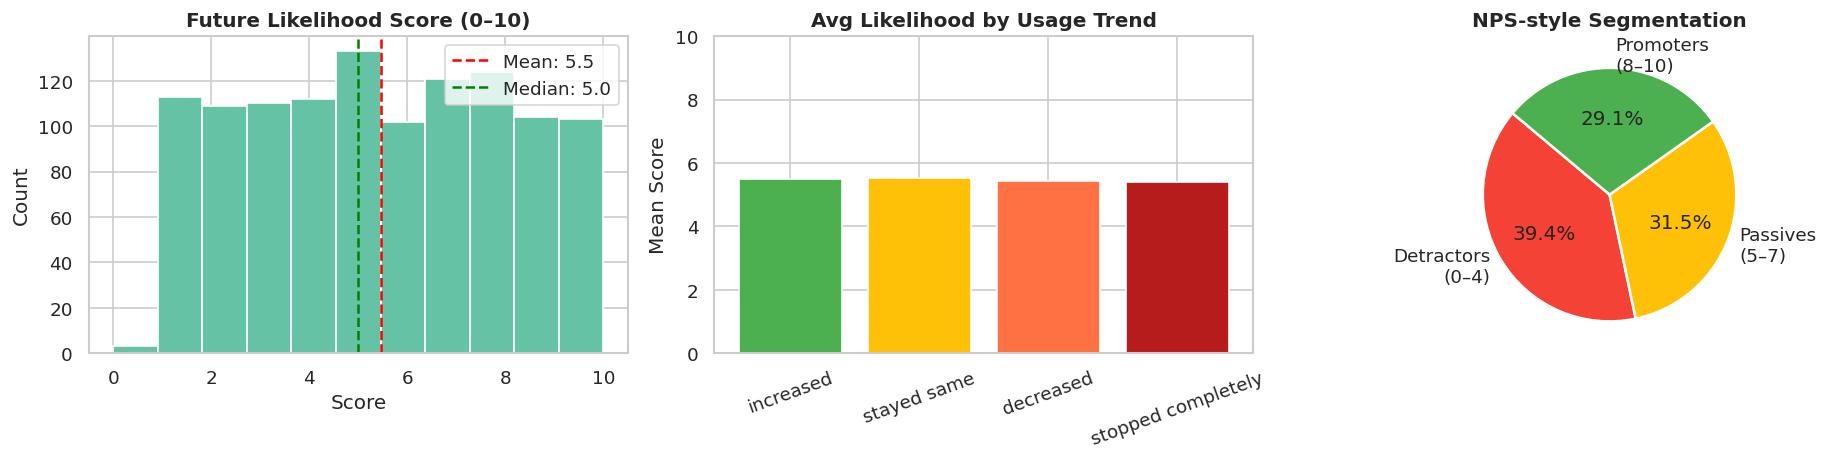

Mean: 5.46 | Median: 5.0 | Std: 2.84
Promoters: 330 | Passives: 357 | Detractors: 447


In [19]:
fl = df['future_likelihood'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution
axes[0].hist(fl, bins=11, color=COLORS[0], edgecolor='white')
axes[0].axvline(fl.mean(), color='red', linestyle='--', label=f'Mean: {fl.mean():.1f}')
axes[0].axvline(fl.median(), color='green', linestyle='--', label=f'Median: {fl.median():.1f}')
axes[0].set_title('Future Likelihood Score (0–10)', fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# By wiki usage change
df_fl = df[['wiki_usage_change_clean','future_likelihood']].dropna()
df_fl = df_fl[df_fl['wiki_usage_change_clean'].isin(change_order)]
means_by_change = df_fl.groupby('wiki_usage_change_clean')['future_likelihood'].mean().reindex(change_order)
axes[1].bar(change_order, means_by_change.values,
            color=['#4CAF50','#FFC107','#FF7043','#B71C1C'])
axes[1].set_title('Avg Likelihood by Usage Trend', fontweight='bold')
axes[1].set_ylabel('Mean Score')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylim(0, 10)

# NPS-style segmentation
detractors  = (fl < 5).sum()
passives    = ((fl >= 5) & (fl < 8)).sum()
promoters   = (fl >= 8).sum()
axes[2].pie([detractors, passives, promoters],
            labels=['Detractors\n(0–4)','Passives\n(5–7)','Promoters\n(8–10)'],
            autopct='%1.1f%%',
            colors=['#F44336','#FFC107','#4CAF50'],
            startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[2].set_title('NPS-style Segmentation', fontweight='bold')

plt.tight_layout()
plt.savefig('likelihood.png', bbox_inches='tight')
plt.show()
print(f'Mean: {fl.mean():.2f} | Median: {fl.median()} | Std: {fl.std():.2f}')
print(f'Promoters: {promoters} | Passives: {passives} | Detractors: {detractors}')

## 15. Correlation: Platform Preference vs Likelihood Score

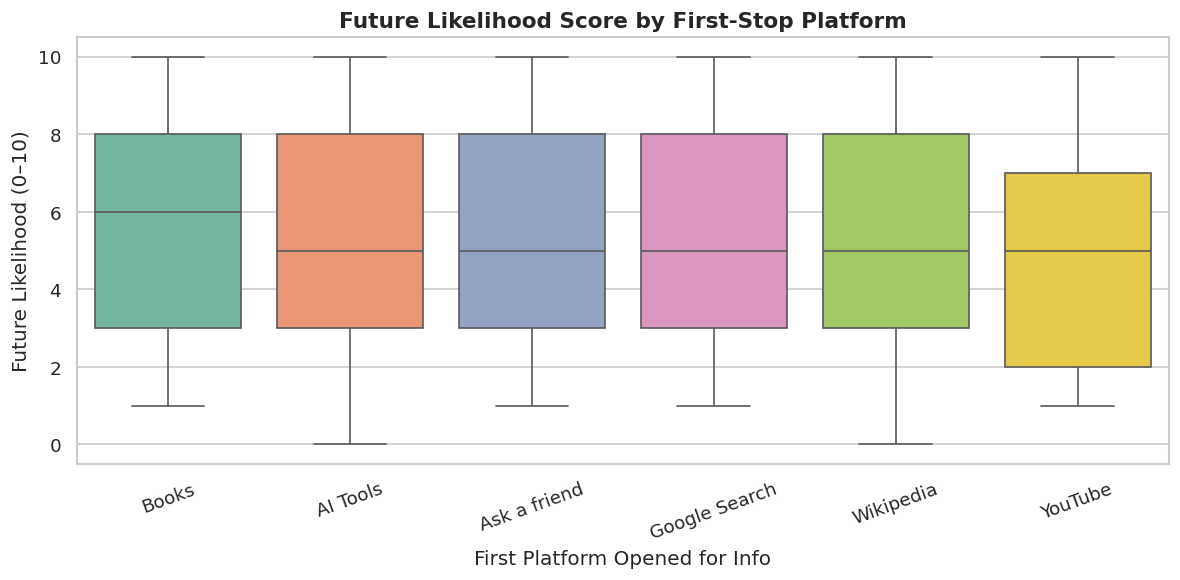

In [20]:
# Encode first_open as numeric
fo_map = {'Wikipedia':3, 'Google Search':2, 'Books':2, 'YouTube':1, 'AI Tools':0, 'Ask a friend':1}
df['first_open_num'] = df['first_open'].str.strip().map(fo_map)

# Box plot of likelihood by first-open choice
plt.figure(figsize=(10, 5))
fo_order = df.groupby('first_open')['future_likelihood'].median().sort_values(ascending=False).index
df_box = df[['first_open','future_likelihood']].dropna()
sns.boxplot(data=df_box, x='first_open', y='future_likelihood',
            order=fo_order, palette='Set2')
plt.title('Future Likelihood Score by First-Stop Platform', fontweight='bold', fontsize=13)
plt.xlabel('First Platform Opened for Info')
plt.ylabel('Future Likelihood (0–10)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('boxplot_likelihood.png', bbox_inches='tight')
plt.show()

## 16. Heatmap – Frustration vs AI Summary Interest

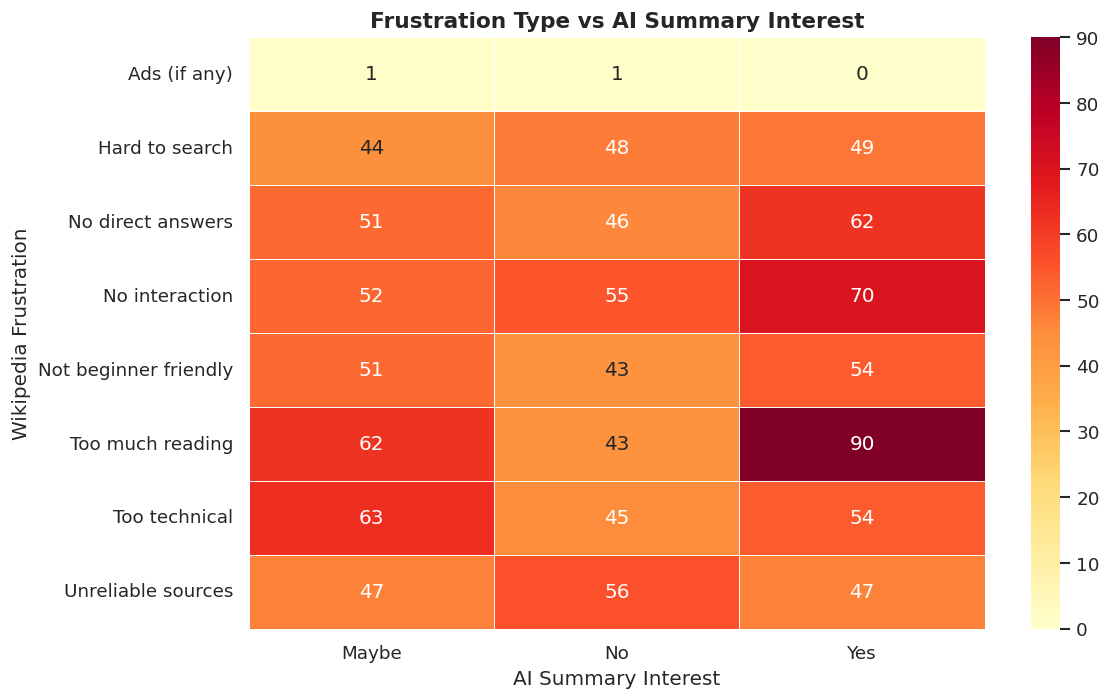

In [21]:
hmap = pd.crosstab(
    df['frustration_wiki'].str.strip(),
    df['ai_summary_interest'].str.strip()
)
plt.figure(figsize=(10, 6))
sns.heatmap(hmap, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Frustration Type vs AI Summary Interest', fontweight='bold', fontsize=13)
plt.xlabel('AI Summary Interest')
plt.ylabel('Wikipedia Frustration')
plt.tight_layout()
plt.savefig('heatmap_frustration.png', bbox_inches='tight')
plt.show()

## 17. Segmentation: Heavy Wikipedia Users vs Non-Users

In [22]:
heavy_wiki = df['wiki_freq'].isin(['Daily','Multiple times a day'])
non_wiki   = df['wiki_freq'].isin(['Never','Rarely','Yearly'])

seg_summary = pd.DataFrame({
    'Heavy Wiki Users': [
        df[heavy_wiki]['future_likelihood'].mean().round(2),
        df[heavy_wiki]['trust_more'].eq('Wikipedia').mean().round(2),
        df[heavy_wiki]['age'].mean().round(1),
        len(df[heavy_wiki])
    ],
    'Low/No Wiki Users': [
        df[non_wiki]['future_likelihood'].mean().round(2),
        df[non_wiki]['trust_more'].eq('Wikipedia').mean().round(2),
        df[non_wiki]['age'].mean().round(1),
        len(df[non_wiki])
    ]
}, index=['Avg Likelihood Score','% Trust Wikipedia','Avg Age','N Respondents'])

print(seg_summary.to_string())
seg_summary

                      Heavy Wiki Users  Low/No Wiki Users
Avg Likelihood Score              5.58               5.22
% Trust Wikipedia                 0.18               0.19
Avg Age                          20.70              20.80
N Respondents                   190.00             368.00


,Heavy Wiki Users,Low/No Wiki Users
Avg Likelihood Score,5.58,5.22
% Trust Wikipedia,0.18,0.19
Avg Age,20.70,20.80
N Respondents,190.00,368.00


## 18. Survey Response Time Distribution

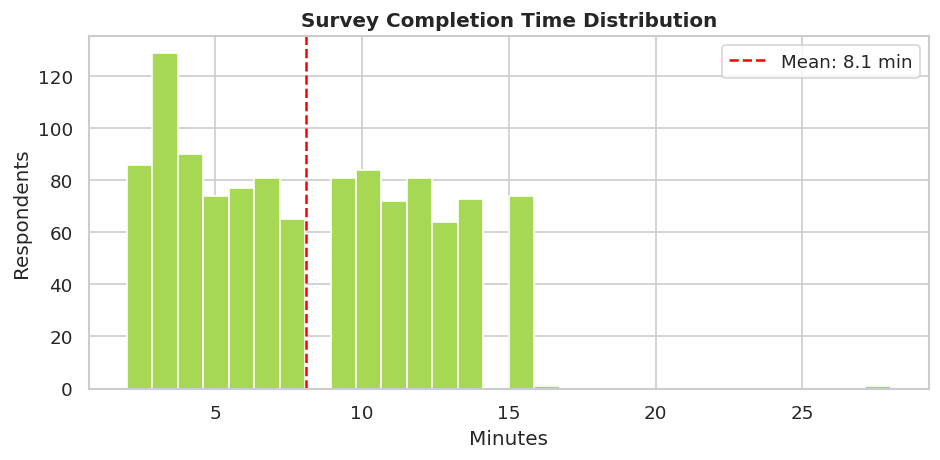

count    1134.000000
mean        8.141093
std         4.355904
min         2.000000
25%         4.000000
50%         8.000000
75%        12.000000
max        53.000000
Name: response_time_min, dtype: float64


In [23]:
rt = df['response_time_min'].dropna()
rt_filtered = rt[rt < 30]  # remove extreme outliers for readability

plt.figure(figsize=(8, 4))
plt.hist(rt_filtered, bins=30, color=COLORS[4], edgecolor='white')
plt.axvline(rt_filtered.mean(), color='red', linestyle='--',
            label=f'Mean: {rt_filtered.mean():.1f} min')
plt.title('Survey Completion Time Distribution', fontweight='bold')
plt.xlabel('Minutes')
plt.ylabel('Respondents')
plt.legend()
plt.tight_layout()
plt.savefig('response_time.png', bbox_inches='tight')
plt.show()
print(rt.describe())

## 19. Responses Over Time (Survey Activity)

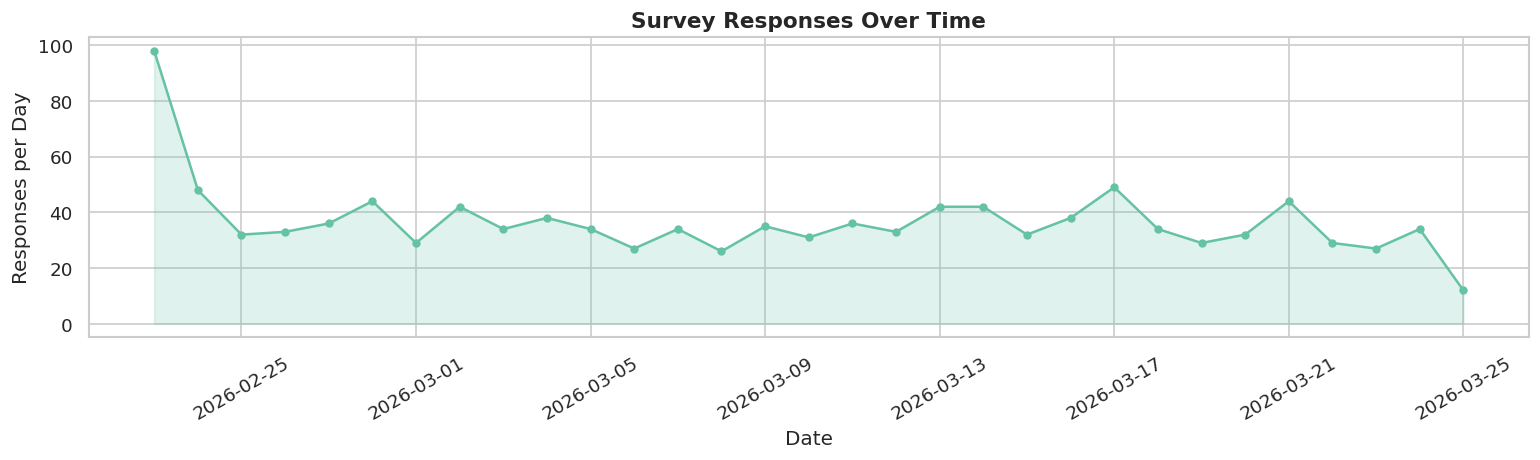

In [24]:
daily_resp = df.groupby('survey_date').size().reset_index(name='responses')

plt.figure(figsize=(13, 4))
plt.plot(daily_resp['survey_date'], daily_resp['responses'],
         marker='o', markersize=4, linewidth=1.5, color=COLORS[0])
plt.fill_between(daily_resp['survey_date'], daily_resp['responses'],
                 alpha=0.2, color=COLORS[0])
plt.title('Survey Responses Over Time', fontweight='bold', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Responses per Day')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('responses_over_time.png', bbox_inches='tight')
plt.show()

## 20. Business Insights Summary

In [25]:
insights = """
========================================================
  WIKIPEDIA BUSINESS ANALYTICS – KEY INSIGHTS SUMMARY
========================================================

1. USER DECLINE IS REAL
   - Majority of respondents report decreased or completely
     stopped Wikipedia usage in the last 2 years.
   - AI tools now dominate daily usage frequency.

2. AI TOOLS ARE THE #1 FIRST STOP
   - Most users open AI Tools first for information needs,
     surpassing Wikipedia and Google Search.

3. TRUST IS SPLIT – BUT WIKIPEDIA HOLDS CREDIBILITY
   - A significant share still trusts Wikipedia more or
     equally compared to AI tools.
   - AI trust concern: 'risk of incorrect answers' is top
     negative perception of AI tools.

4. TOP PAIN POINTS FOR WIKIPEDIA
   - Too much reading / lengthy articles
   - Hard to navigate
   - Not beginner friendly
   - Outdated information

5. STRONG DEMAND FOR AI INTEGRATION
   - Majority would use Wikipedia MORE if it had AI summaries.
   - 'AI summary + Original Wikipedia article' is the preferred
     hybrid format across all user segments.

6. TOP REQUESTED FEATURES
   - Simplified student mode
   - Chat-style explanations
   - Interactive Q&A
   - Personalized recommendations

7. PLATFORM HEALTH (NPS-STYLE METRIC)
   - Mean future likelihood score is moderate (~5–6).
   - A sizable detractor group (0–4) signals churn risk.
   - Users who still use Wikipedia daily have significantly
     higher likelihood scores than non-users.

8. STRATEGIC RECOMMENDATION
   - Wikipedia must add AI-powered features (summaries,
     Q&A, simplified mode) to retain Gen-Z users.
   - Lean into its credibility advantage over AI tools
     by adding source transparency and fact-check layers.
   - A 'Student Mode' could reduce 'too complex' perception
     and re-engage the largest user segment (Engineering, 18–21).

========================================================
"""
print(insights)


  WIKIPEDIA BUSINESS ANALYTICS – KEY INSIGHTS SUMMARY

1. USER DECLINE IS REAL
   - Majority of respondents report decreased or completely
     stopped Wikipedia usage in the last 2 years.
   - AI tools now dominate daily usage frequency.

2. AI TOOLS ARE THE #1 FIRST STOP
   - Most users open AI Tools first for information needs,
     surpassing Wikipedia and Google Search.

3. TRUST IS SPLIT – BUT WIKIPEDIA HOLDS CREDIBILITY
   - A significant share still trusts Wikipedia more or
     equally compared to AI tools.
   - AI trust concern: 'risk of incorrect answers' is top
     negative perception of AI tools.

4. TOP PAIN POINTS FOR WIKIPEDIA
   - Too much reading / lengthy articles
   - Hard to navigate
   - Not beginner friendly
   - Outdated information

5. STRONG DEMAND FOR AI INTEGRATION
   - Majority would use Wikipedia MORE if it had AI summaries.
   - 'AI summary + Original Wikipedia article' is the preferred
     hybrid format across all user segments.

6. TOP REQUESTED FEAT